# Dataset analysis — 70 Martini 3 membrane compositions

A characterisation of the 70-system dataset that the GNN is trained against.
Reads the precomputed property files in `results/properties/` (one pickle per
composition, despite the `.h5` extension) and the parsed compositions.

Sections:
1. Composition catalogue + coverage heatmap
2. Property definitions (annotated from `lipid_gnn.functions_emil.calculate_properties`)
3. Univariate distributions
4. Pairwise structure: correlations, pairplot, Helfrich sanity check
5. Composition titration curves (POPC + X families)
6. Dimensionality reduction & clustering (PCA, UMAP if available, hierarchical)
7. Time-series quality (stationarity, autocorrelation, noise floor)
8. Train/val/test split audit

**Outputs**: `results/dataset_analysis/figures/*.{png,pdf}` and
`results/dataset_analysis/dataset_table.csv`.


In [1]:
import pickle
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

from lipid_gnn.config import CONFIG

PROPS_DIR = Path(CONFIG.paths.props_dir)
OUT_DIR   = Path(CONFIG.paths.results_dir) / 'dataset_analysis'
FIG_DIR   = OUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

PROPS = list(CONFIG.vocab.all_properties)
LIPIDS = list(CONFIG.vocab.lipid_types)
REFERENCE = CONFIG.dataset.reference_system  # 'POPC100'

# Optional UMAP
try:
    import umap as umap_lib
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print('[INFO] umap-learn not installed — Section 6 falls back to PCA-only.')

print(f'props dir: {PROPS_DIR}')
print(f'output  : {OUT_DIR}')
print(f'{len(LIPIDS)} lipid types, {len(PROPS)} properties')


props dir: /home/phillip/Goethe/Thesis/lipid-graph-nn/results/properties
output  : /home/phillip/Goethe/Thesis/lipid-graph-nn/results/dataset_analysis
10 lipid types, 8 properties


## 1 — Composition catalogue

The 70 filenames encode binary compositions like `POPC70_CHOL30` or pure systems
`POPC100`. We parse `(lipid_A, frac_A, lipid_B, frac_B)` and load the
8 mean properties for each.

In [2]:
# Lipid family taxonomy (headgroup + tail saturation)
LIPID_FAMILY = {
    'POPC': 'PC (mono-unsat)',  # reference
    'DOPC': 'PC (di-unsat)',
    'DIPC': 'PC (di-unsat)',
    'DPPC': 'PC (saturated)',
    'POPE': 'PE',
    'DOPE': 'PE',
    'DPPE': 'PE',
    'POPS': 'PS (anionic)',
    'DOPS': 'PS (anionic)',
    'CHOL': 'sterol',
}
FAMILY_ORDER = ['PC (mono-unsat)', 'PC (di-unsat)', 'PC (saturated)', 'PE', 'PS (anionic)', 'sterol']
FAMILY_COLORS = dict(zip(FAMILY_ORDER, plt.get_cmap('tab10').colors[:len(FAMILY_ORDER)]))

_PARSE = re.compile(r'([A-Z]+)(\d+)')

def parse_composition(stem):
    """Parse 'POPC70_CHOL30' → (POPC, 70, CHOL, 30); 'POPC100' → (POPC, 100, None, 0)."""
    parts = _PARSE.findall(stem)
    if len(parts) == 1:
        lip, frac = parts[0]
        return lip, int(frac), None, 0
    (a, fa), (b, fb) = parts[:2]
    return a, int(fa), b, int(fb)

def partner(lip_a, lip_b):
    """Non-POPC component (or the only component if pure)."""
    if lip_a == 'POPC':
        return lip_b if lip_b is not None else 'POPC'
    if lip_b == 'POPC':
        return lip_a
    return lip_a  # pure non-POPC (DIPC100, DOPC100, DPPC100)

def partner_frac(lip_a, fa, lip_b, fb):
    """Mole fraction of the partner lipid (the non-POPC one)."""
    if lip_b is None:
        return 0 if lip_a == 'POPC' else 100
    return fb if lip_a == 'POPC' else fa


In [3]:
def load_one(path):
    with open(path, 'rb') as f:
        mean_dict, raw_dict = pickle.load(f)
    return mean_dict, raw_dict

rows = []
RAW = {}  # composition → raw_dict (used in Section 7)

for p in sorted(PROPS_DIR.glob('*.h5')):
    mean_d, raw_d = load_one(p)
    a, fa, b, fb = parse_composition(p.stem)
    row = {
        'composition': p.stem,
        'lipid_a': a, 'frac_a': fa,
        'lipid_b': b, 'frac_b': fb,
        'partner': partner(a, b),
        'partner_frac': partner_frac(a, fa, b, fb),
        'is_pure': b is None,
    }
    row['family'] = LIPID_FAMILY[row['partner']] if row['partner_frac'] > 0 or row['is_pure'] else 'PC (mono-unsat)'
    for k in PROPS:
        row[k] = float(mean_d[k])
    rows.append(row)
    RAW[p.stem] = raw_d

df = pd.DataFrame(rows).sort_values('composition').reset_index(drop=True)
print(f'loaded {len(df)} compositions')
df.head(8)


loaded 70 compositions


,composition,lipid_a,frac_a,lipid_b,frac_b,partner,partner_frac,is_pure,family,lipid_packing,thickness,thickness_std,compressibility,bending_modulus,persistence,diffusivity,variation
0,DIPC100,DIPC,100,None,0,DIPC,100,True,PC (di-unsat),2.617286,34.710969,2.269160,5.375792,118.791539,0.053086,1282.886108,0.282479
1,DOPC100,DOPC,100,None,0,DOPC,100,True,PC (di-unsat),2.896163,37.702380,2.098792,4.608511,151.229010,0.071958,860.586365,0.261547
2,DPPC100,DPPC,100,None,0,DPPC,100,True,PC (saturated),3.328745,41.815721,2.059277,4.514817,155.119180,0.070723,658.374878,0.241353
3,POPC100,POPC,100,None,0,POPC,0,True,PC (mono-unsat),3.015460,38.881588,2.154535,4.885916,151.937595,0.078131,757.353149,0.257273
4,POPC10_DIPC90,POPC,10,DIPC,90,DIPC,90,False,PC (di-unsat),2.651521,35.122556,2.287244,5.458995,122.762030,0.058554,1249.631592,0.280026
5,POPC10_DOPC90,POPC,10,DOPC,90,DOPC,90,False,PC (di-unsat),2.905172,37.769299,2.099492,4.596000,160.119861,0.066314,868.113708,0.261043
6,POPC10_DPPC90,POPC,10,DPPC,90,DPPC,90,False,PC (saturated),3.281087,41.399950,2.113486,4.730868,174.965332,0.084656,669.376343,0.243458
7,POPC20_DIPC80,POPC,20,DIPC,80,DIPC,80,False,PC (di-unsat),2.691797,35.476152,2.332826,5.710843,110.897430,0.055908,1211.253784,0.278091


In [4]:
# Save the master table for downstream reuse
table_path = OUT_DIR / 'dataset_table.csv'
df.to_csv(table_path, index=False)
print(f'wrote {table_path}')


wrote /home/phillip/Goethe/Thesis/lipid-graph-nn/results/dataset_analysis/dataset_table.csv


### 1a — Coverage of the composition space

Each non-POPC partner lipid is paired with POPC at a discrete set of fractions.
The heatmap below shows, for every (partner × fraction) cell, whether that
composition was simulated. Pure systems (DIPC100, DOPC100, DPPC100, POPC100)
appear in the rightmost / dedicated columns.

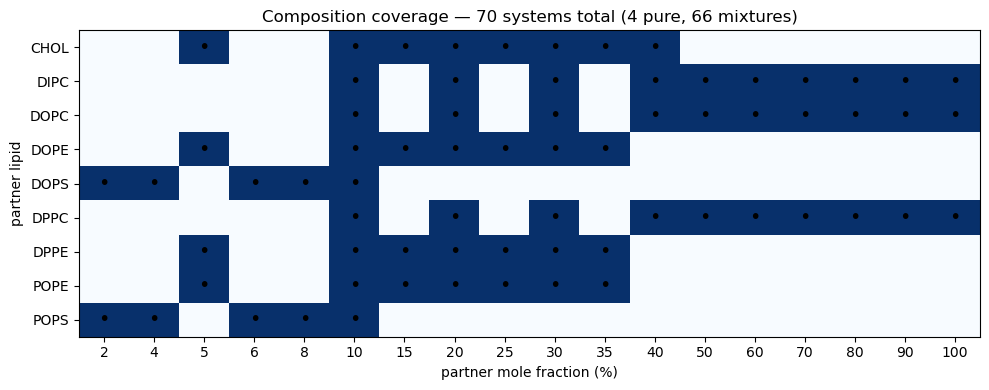


Pure systems present: ['DIPC100', 'DOPC100', 'DPPC100', 'POPC100']
Partners with pure data: ['DIPC', 'DOPC', 'DPPC']


In [5]:
partners = sorted(set(df['partner']) - {'POPC'})
fracs = sorted(set(df['partner_frac']) - {0})  # 0 = POPC100

cov = np.zeros((len(partners), len(fracs)), dtype=int)
for _, r in df.iterrows():
    if r['partner'] == 'POPC':
        continue
    pi = partners.index(r['partner'])
    fi = fracs.index(r['partner_frac'])
    cov[pi, fi] = 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(cov, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(fracs))); ax.set_xticklabels(fracs)
ax.set_yticks(range(len(partners))); ax.set_yticklabels(partners)
ax.set_xlabel('partner mole fraction (%)')
ax.set_ylabel('partner lipid')
ax.set_title(f'Composition coverage — {len(df)} systems total ({(df["is_pure"]).sum()} pure, {(~df["is_pure"]).sum()} mixtures)')
for i in range(len(partners)):
    for j in range(len(fracs)):
        if cov[i, j]:
            ax.text(j, i, '•', ha='center', va='center', color='black', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / '01_coverage.png', dpi=150, bbox_inches='tight')
plt.savefig(FIG_DIR / '01_coverage.pdf', bbox_inches='tight')
plt.show()

print('\nPure systems present:', sorted(df.loc[df['is_pure'], 'composition'].tolist()))
print('Partners with pure data:', sorted(set(df.loc[df['is_pure'], 'lipid_a']) - {'POPC'}))


## 2 — Property definitions

Eight scalars are computed per composition by
`lipid_gnn.functions_emil.calculate_properties.compute_properties` over frames
`[50:667]` (≈1 µs of production after a 50-frame equilibration discard,
`dt=1.5 ns`).

| Name | Definition | Units |
|---|---|---|
| `lipid_packing` | N_lipids / box_x · box_y, frame-mean | lipids / nm² |
| `thickness` | mean (upper − lower) leaflet height on a 0.1 nm xy grid | Å |
| `thickness_std` | frame-mean of the spatial std of (upper − lower) | Å |
| `compressibility` | variance of thickness deviations on the grid (×100) | Å³ / kT |
| `bending_modulus` | κ from a `kBT/(κ q⁴)` fit of the radially-binned undulation spectrum | kT / Å³ |
| `persistence` | P(lipid–lipid contact still present after `lag=50` frames), `cutoff=0.7 nm` | dimensionless |
| `diffusivity` | mean lateral squared displacement after `lag=10` frames (×100) | Å² |
| `variation` | mean Voronoi-cell-area coefficient of variation (per leaflet, then averaged) | dimensionless |

#### Implementation notes

- **Thickness** uses `LinearNDInterpolator` on PO4 beads. The leaflet split is
  the largest gap in sorted z (`calculate_properties.py:206-209`). Frames where
  the interpolator returns NaNs anywhere on the grid are silently dropped.
- **Compressibility** is computed as the variance of `xy_thickness − thickness_series[:, None]`
  on the 0.1 nm grid (`:335-337`) — this is a thickness-fluctuation variance,
  not the canonical area-compressibility modulus K_A (which would use total
  area fluctuations). Treat it as a thickness-curvature noise measure.
- **Bending modulus** is fit on q > 0.1 nm⁻¹ from the radially-binned 2D-FFT
  spectrum of the midplane height (`:90-110`). Few q-bins survive the bin-count
  threshold, so this property is the noisiest of the eight (flagged in the
  memory bank).
- **Persistence and diffusivity** sample `probe_size=10` random lipids per frame.
  Both routines have a leaflet-selection identity bug: the if/else branches
  pick the same lipids (`< cutoff` in both, `:238-241` and `:282-285`). Effective
  sampling is leaflet-mixed but still random, so the means remain meaningful;
  flagging here for thesis transparency.
- **Variation** computes Voronoi CV per leaflet then averages. Cells touching
  the periodic box are clipped to the box (`shapely`).

The `mean_dict[prop]` scalar is what the GNN regresses against;
`raw_dict[prop]` is the per-frame series (used in Section 7), except for
`bending_modulus` whose "raw" entry is the (q_centers, power_spectrum) pair
from the spectrum fit, not a time series.


## 3 — Univariate property distributions

For each property: KDE+rug across the 70 systems, coloured strip by partner
family, with the POPC100 reference value marked. Outliers (|z|>3 via MAD) are
listed below.

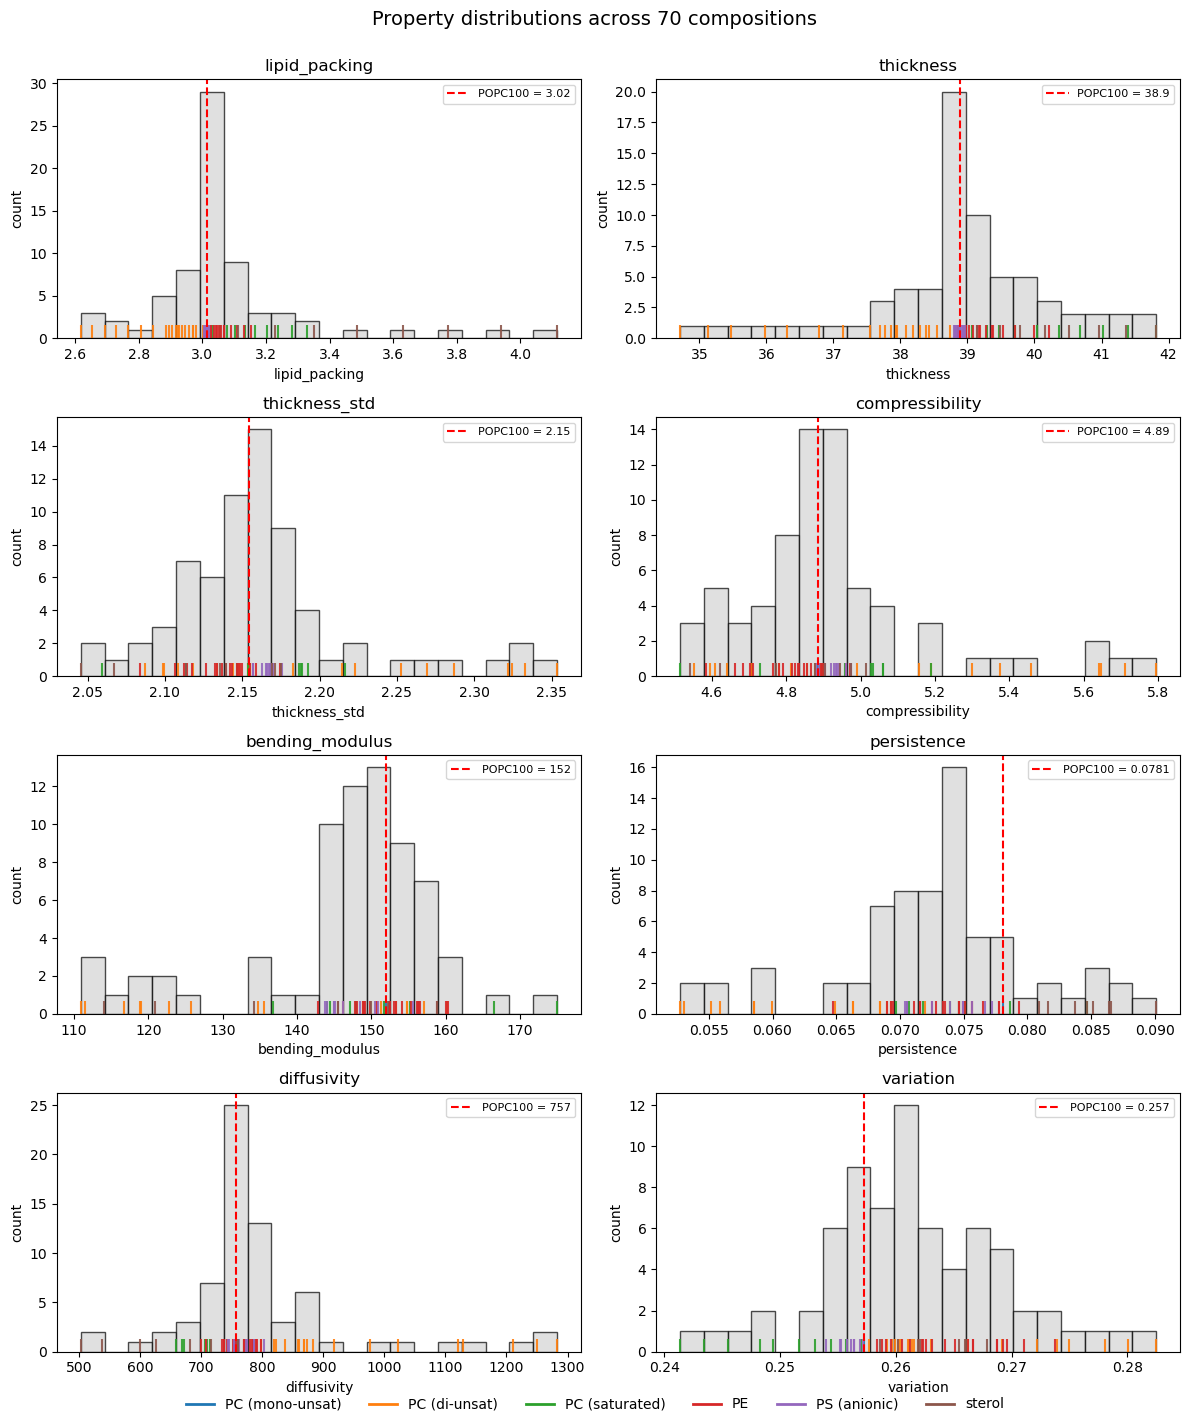

In [6]:
ref_row = df[df['composition'] == REFERENCE].iloc[0]

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
for ax, prop in zip(axes.flat, PROPS):
    vals = df[prop].values
    # histogram
    ax.hist(vals, bins=20, color='lightgray', edgecolor='k', alpha=0.7)
    # rug coloured by family
    ymax = ax.get_ylim()[1]
    for fam, color in FAMILY_COLORS.items():
        mask = df['family'] == fam
        if mask.any():
            ax.vlines(df.loc[mask, prop], 0, ymax * 0.05, color=color, alpha=0.9, lw=1.5)
    # POPC100 reference
    ax.axvline(ref_row[prop], color='red', linestyle='--', lw=1.5, label=f'POPC100 = {ref_row[prop]:.3g}')
    ax.set_title(prop)
    ax.set_xlabel(prop); ax.set_ylabel('count')
    ax.legend(fontsize=8, loc='upper right')

# Single legend for families
handles = [plt.Line2D([0], [0], color=c, lw=2) for c in FAMILY_COLORS.values()]
fig.legend(handles, list(FAMILY_COLORS.keys()), loc='lower center',
           ncol=len(FAMILY_COLORS), bbox_to_anchor=(0.5, -0.01), frameon=False)
fig.suptitle('Property distributions across 70 compositions', y=1.0, fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / '03_univariate.png', dpi=150, bbox_inches='tight')
plt.savefig(FIG_DIR / '03_univariate.pdf', bbox_inches='tight')
plt.show()


In [7]:
# Summary statistics + outlier flagging via MAD
def mad_z(x):
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 0.6745 * (x - med) / (mad if mad > 0 else 1.0)

summary = []
outlier_rows = []
for prop in PROPS:
    v = df[prop].values
    z = mad_z(v)
    out_mask = np.abs(z) > 3
    summary.append({
        'property': prop,
        'mean':   v.mean(),
        'median': np.median(v),
        'std':    v.std(ddof=1),
        'min':    v.min(),
        'max':    v.max(),
        'IQR':    np.percentile(v, 75) - np.percentile(v, 25),
        'n_outliers (|z_MAD|>3)': int(out_mask.sum()),
    })
    for idx in np.where(out_mask)[0]:
        outlier_rows.append({
            'composition': df.iloc[idx]['composition'],
            'property':    prop,
            'value':       v[idx],
            'z_MAD':       z[idx],
        })

print('Summary:')
print(pd.DataFrame(summary).to_string(index=False))
print('\nOutliers (|z_MAD| > 3):')
print(pd.DataFrame(outlier_rows).sort_values('z_MAD', key=np.abs, ascending=False).to_string(index=False)
      if outlier_rows else '(none)')


Summary:
       property       mean     median        std        min         max       IQR  n_outliers (|z_MAD|>3)
  lipid_packing   3.068015   3.018650   0.249088   2.617286    4.115826  0.127284                      11
      thickness  38.909772  38.931252   1.383252  34.710969   41.815721  1.024904                       9
  thickness_std   2.162207   2.154709   0.059926   2.045654    2.353578  0.040825                       9
compressibility   4.926340   4.893073   0.262566   4.514817    5.794242  0.190681                       7
bending_modulus 146.390117 149.054999  12.991862 110.897430  174.965332  9.306442                      10
    persistence   0.072661   0.073457   0.007596   0.052734    0.090123  0.006129                       7
    diffusivity 796.445517 771.987518 139.291407 503.069702 1282.886108 58.631363                      12
      variation   0.261505   0.260769   0.007846   0.241353    0.282479  0.009219                       1

Outliers (|z_MAD| > 3):
  compositio

## 4 — Pairwise structure

### 4a — Correlation matrix (Pearson + Spearman)

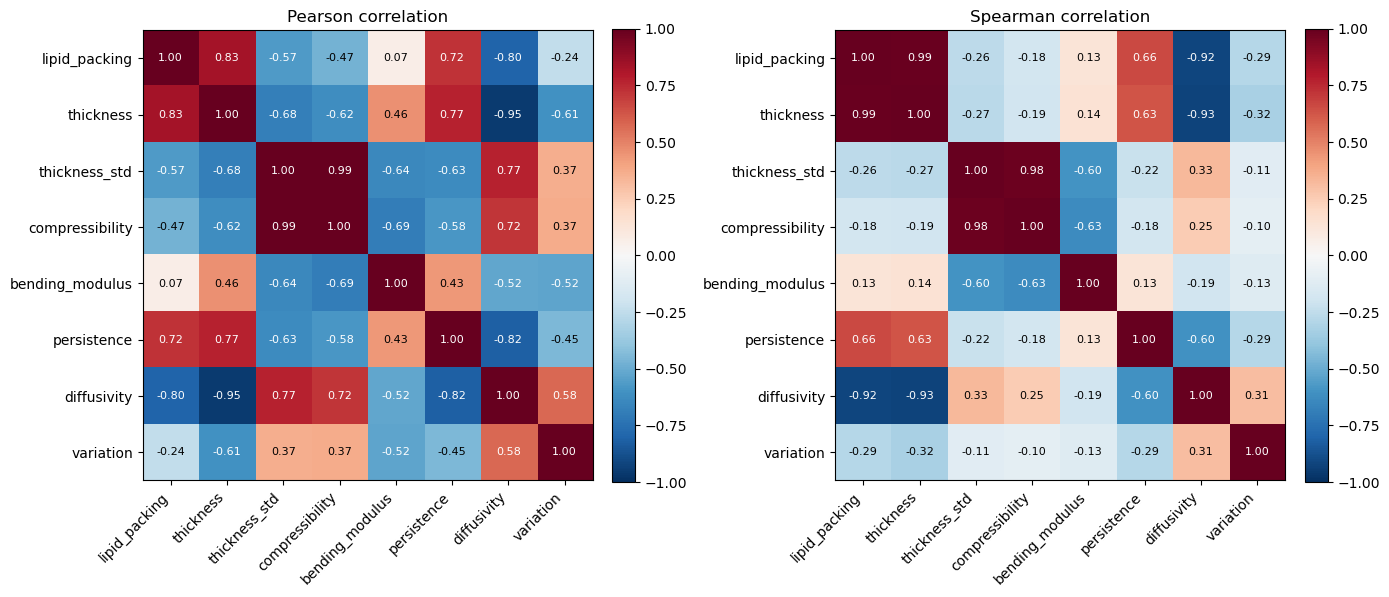

In [8]:
pearson  = df[PROPS].corr(method='pearson')
spearman = df[PROPS].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, mat, title in zip(axes, [pearson, spearman], ['Pearson', 'Spearman']):
    im = ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(PROPS))); ax.set_xticklabels(PROPS, rotation=45, ha='right')
    ax.set_yticks(range(len(PROPS))); ax.set_yticklabels(PROPS)
    ax.set_title(f'{title} correlation')
    for i in range(len(PROPS)):
        for j in range(len(PROPS)):
            ax.text(j, i, f'{mat.iloc[i,j]:.2f}', ha='center', va='center',
                    color='white' if abs(mat.iloc[i,j]) > 0.5 else 'black', fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(FIG_DIR / '04a_correlations.png', dpi=150, bbox_inches='tight')
plt.savefig(FIG_DIR / '04a_correlations.pdf', bbox_inches='tight')
plt.show()


### 4b — Pairplot, coloured by partner family

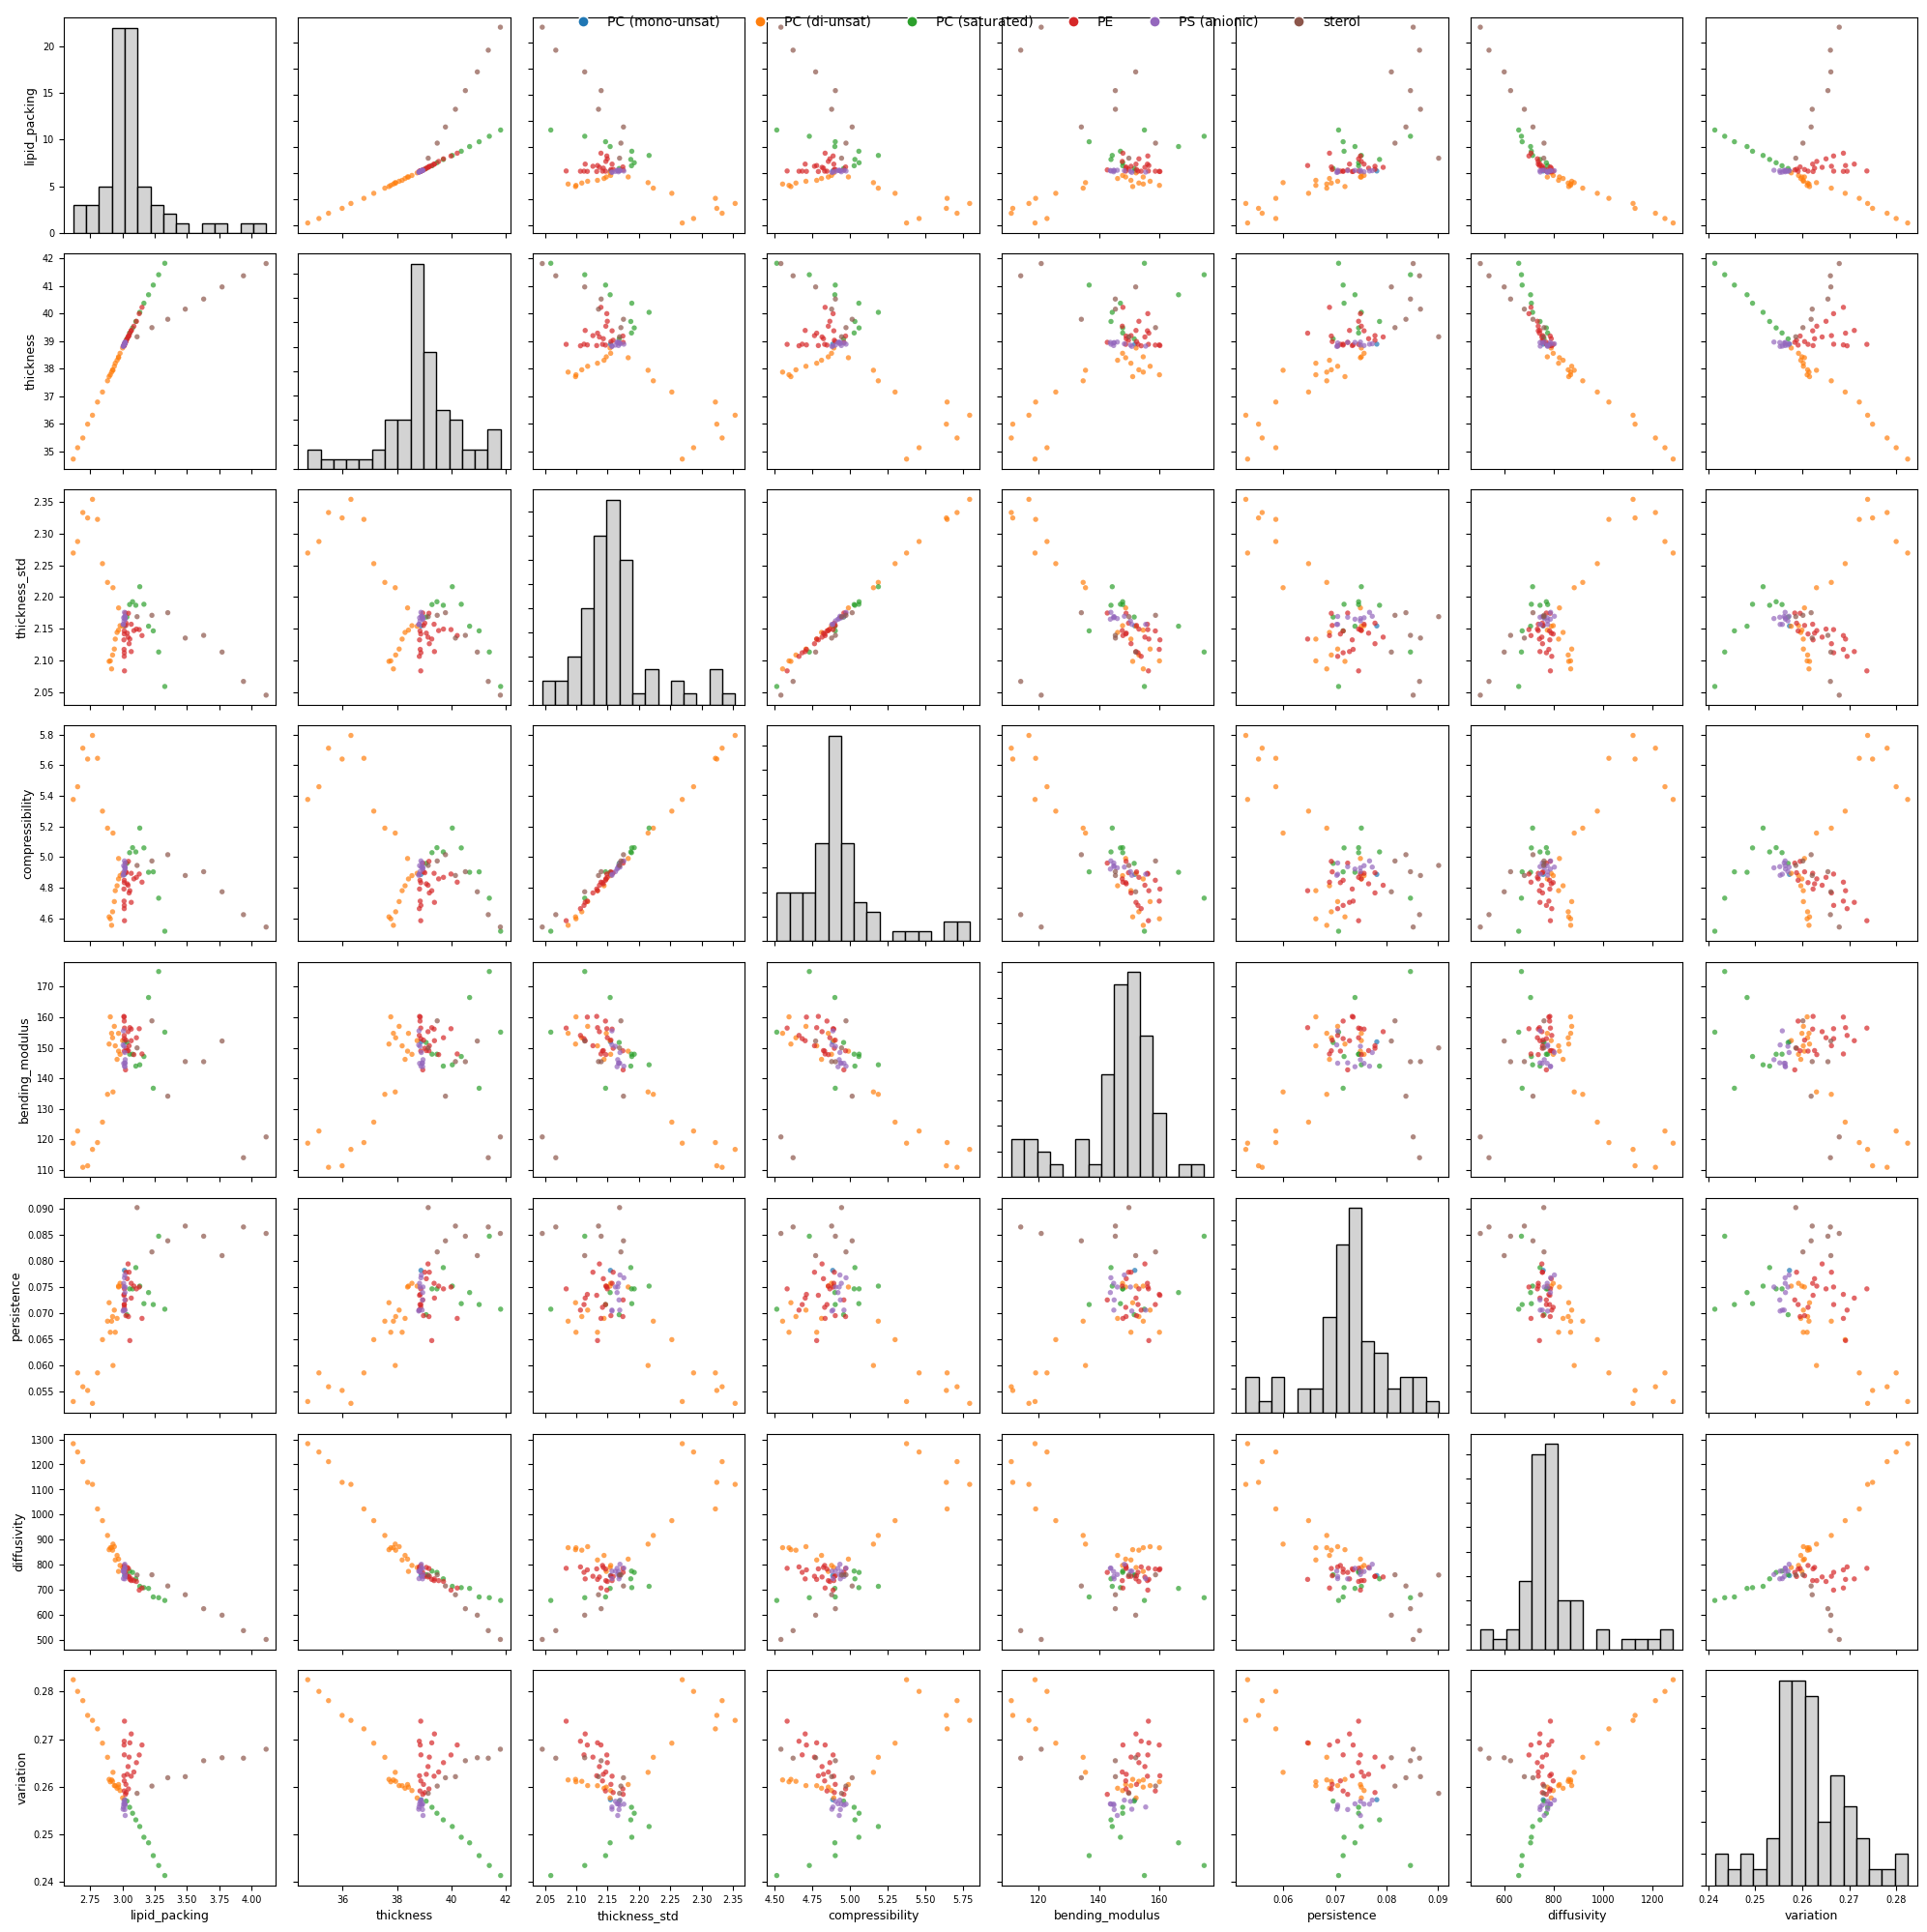

In [9]:
n = len(PROPS)
fig, axes = plt.subplots(n, n, figsize=(20, 20))
for i, py in enumerate(PROPS):
    for j, px in enumerate(PROPS):
        ax = axes[i, j]
        if i == j:
            ax.hist(df[px], bins=15, color='lightgray', edgecolor='k')
        else:
            for fam, color in FAMILY_COLORS.items():
                mask = df['family'] == fam
                if mask.any():
                    ax.scatter(df.loc[mask, px], df.loc[mask, py],
                               c=[color], s=15, alpha=0.7, edgecolor='none')
        if i == n - 1:
            ax.set_xlabel(px, fontsize=9)
        else:
            ax.set_xticklabels([])
        if j == 0:
            ax.set_ylabel(py, fontsize=9)
        else:
            ax.set_yticklabels([])
        ax.tick_params(labelsize=7)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8)
           for c in FAMILY_COLORS.values()]
fig.legend(handles, list(FAMILY_COLORS.keys()), loc='upper center',
           ncol=len(FAMILY_COLORS), bbox_to_anchor=(0.5, 1.0), frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / '04b_pairplot.png', dpi=130, bbox_inches='tight')
plt.savefig(FIG_DIR / '04b_pairplot.pdf', bbox_inches='tight')
plt.show()


### 4c — Helfrich elastic-theory sanity check

For a fluid bilayer, Helfrich theory predicts
`κ ≈ K_A · d² / 24` (with `d` = thickness, `K_A` ≈ area compressibility,
κ = bending modulus). Emil's `compressibility` is a thickness-fluctuation
proxy rather than the strict K_A, but a positive correlation between
`compressibility · thickness²` and `bending_modulus` would still indicate that
the bending fits are not pure noise.

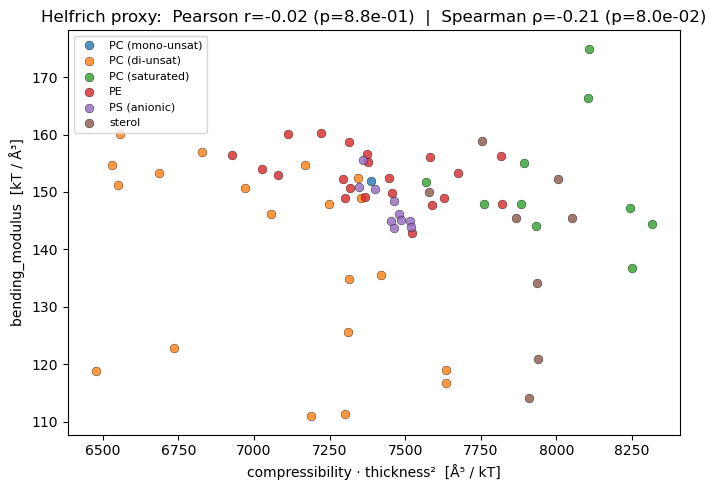

In [10]:
x = df['compressibility'] * df['thickness']**2
y = df['bending_modulus']

r_pear, p_pear = stats.pearsonr(x, y)
r_spear, p_spear = stats.spearmanr(x, y)

fig, ax = plt.subplots(figsize=(7, 5))
for fam, color in FAMILY_COLORS.items():
    m = df['family'] == fam
    ax.scatter(x[m], y[m], c=[color], s=40, alpha=0.8, label=fam, edgecolor='k', lw=0.3)
ax.set_xlabel('compressibility · thickness²  [Å⁵ / kT]')
ax.set_ylabel('bending_modulus  [kT / Å³]')
ax.set_title(f'Helfrich proxy:  Pearson r={r_pear:.2f} (p={p_pear:.1e})  |  Spearman ρ={r_spear:.2f} (p={p_spear:.1e})')
ax.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.savefig(FIG_DIR / '04c_helfrich.png', dpi=150, bbox_inches='tight')
plt.savefig(FIG_DIR / '04c_helfrich.pdf', bbox_inches='tight')
plt.show()


## 5 — Composition titration curves

For each non-POPC partner lipid, plot every property vs partner mole fraction
(0 % = POPC100 anchor; 100 % = pure partner where present). Reveals what
"property knobs" each partner controls.

In [11]:
partners_with_data = sorted(set(df.loc[df['partner_frac'] > 0, 'partner']))
print('Partners with titration data:', partners_with_data)


Partners with titration data: ['CHOL', 'DIPC', 'DOPC', 'DOPE', 'DOPS', 'DPPC', 'DPPE', 'POPE', 'POPS']


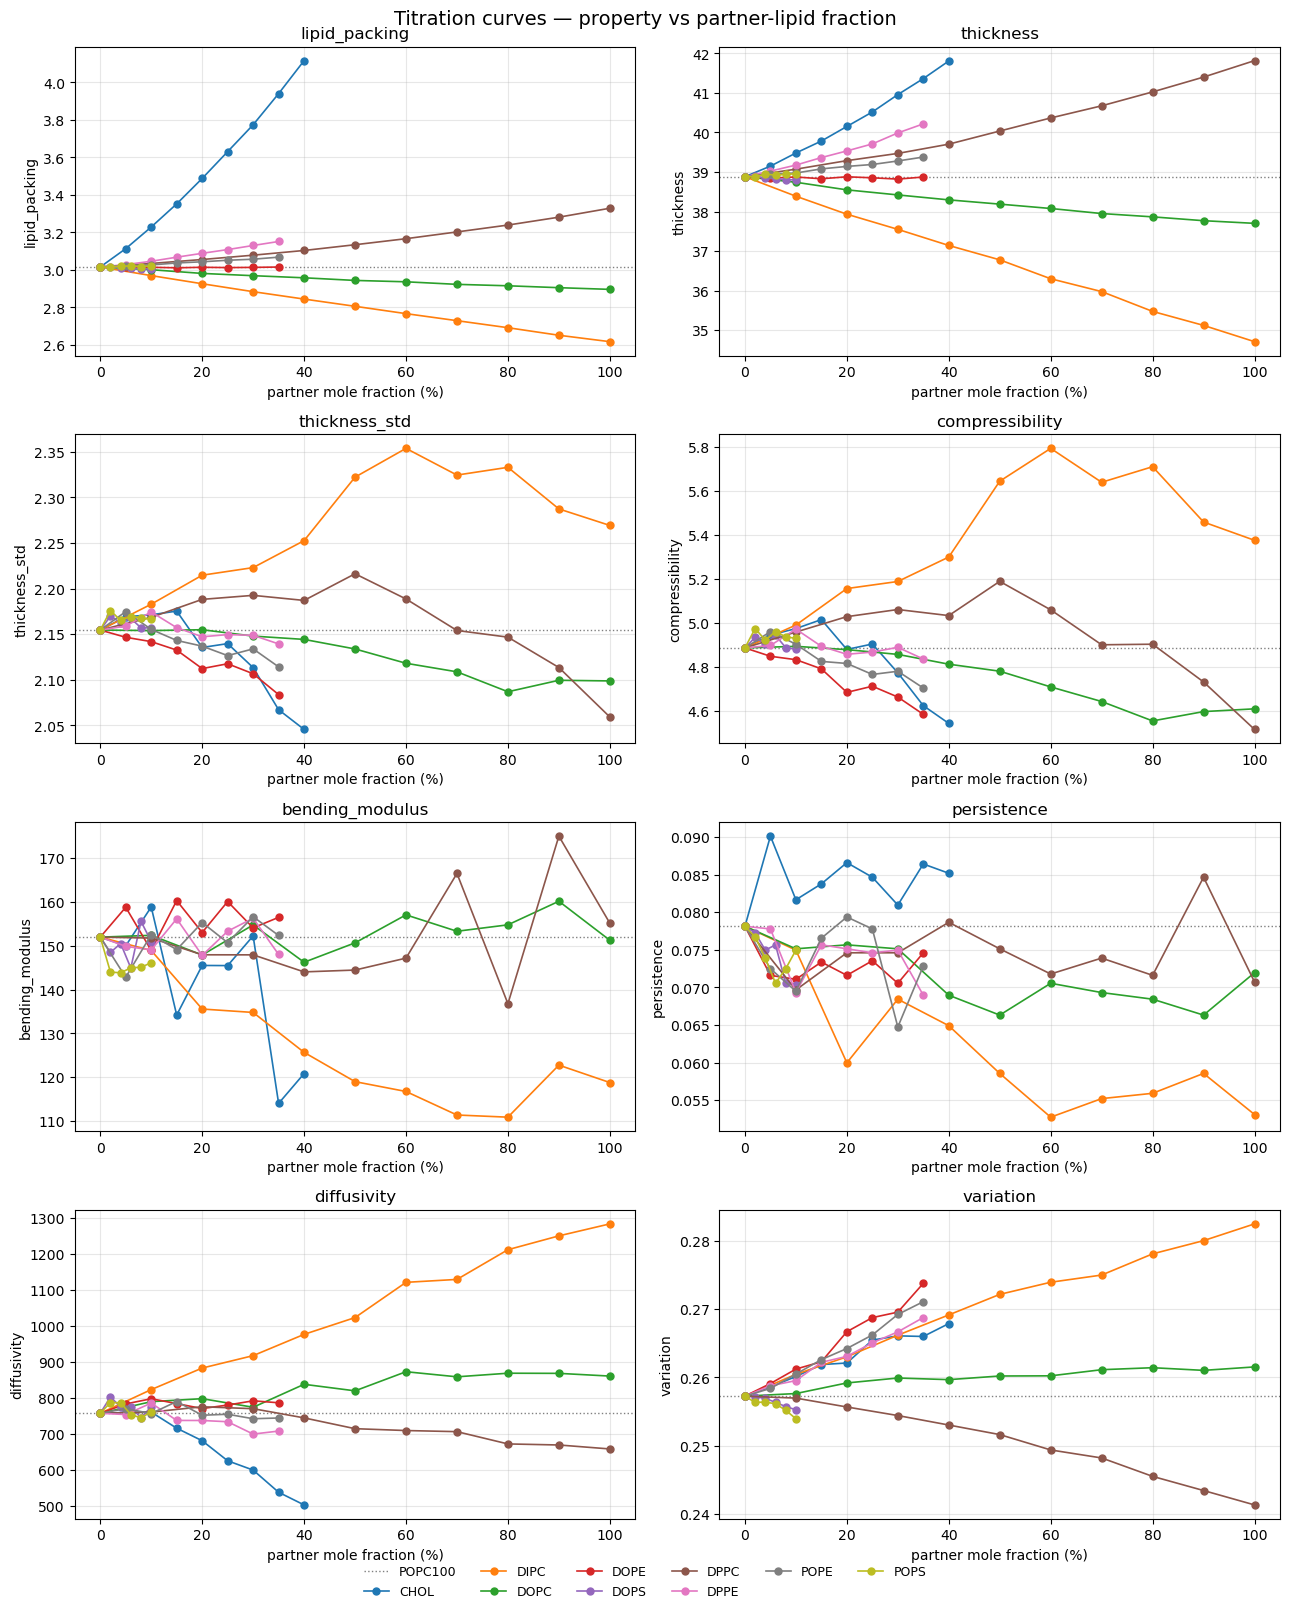

In [12]:
partner_colors = dict(zip(partners_with_data, plt.get_cmap('tab10').colors[:len(partners_with_data)]))

fig, axes = plt.subplots(4, 2, figsize=(13, 16))
for ax, prop in zip(axes.flat, PROPS):
    # POPC100 baseline
    ax.axhline(ref_row[prop], color='gray', linestyle=':', lw=1, label='POPC100')
    for part in partners_with_data:
        m = (df['partner'] == part) | ((df['lipid_a'] == 'POPC') & (df['frac_a'] == 100))
        sub = df[m].sort_values('partner_frac')
        # we want POPC anchor + this partner's titration only
        sub = sub[(sub['partner'] == part) | (sub['composition'] == REFERENCE)]
        sub = sub.sort_values('partner_frac')
        ax.plot(sub['partner_frac'], sub[prop], 'o-', color=partner_colors[part],
                label=part, markersize=5, lw=1.2)
    ax.set_title(prop)
    ax.set_xlabel('partner mole fraction (%)')
    ax.set_ylabel(prop)
    ax.grid(alpha=0.3)

# Compact shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=min(len(labels), 6),
           bbox_to_anchor=(0.5, -0.02), frameon=False, fontsize=9)
fig.suptitle('Titration curves — property vs partner-lipid fraction', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_titration.png', dpi=150, bbox_inches='tight')
plt.savefig(FIG_DIR / '05_titration.pdf', bbox_inches='tight')
plt.show()


## 6 — Dimensionality reduction & clustering

All 8 properties z-scored, then projected. Coloured by partner family.

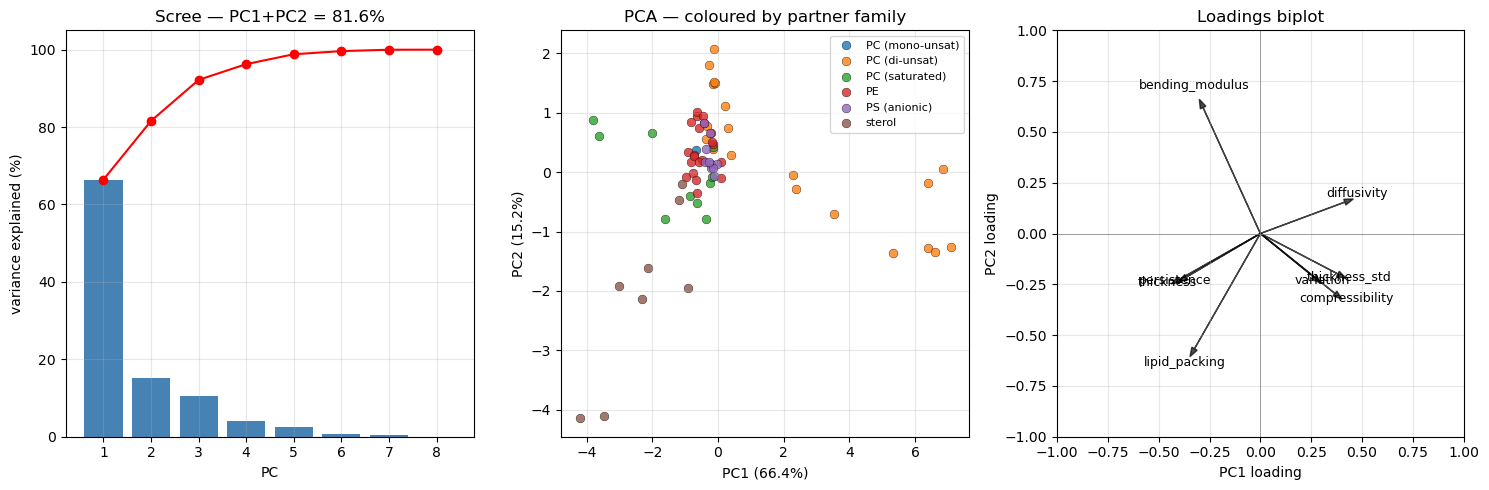

In [13]:
X = df[PROPS].values
X_z = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=min(8, X_z.shape[1]))
Z_pca = pca.fit_transform(X_z)
explained = pca.explained_variance_ratio_

fig = plt.figure(figsize=(15, 5))

# Scree
ax = fig.add_subplot(1, 3, 1)
ax.bar(range(1, len(explained)+1), explained * 100, color='steelblue')
ax.plot(range(1, len(explained)+1), np.cumsum(explained) * 100, 'ro-', lw=1.5)
ax.set_xlabel('PC'); ax.set_ylabel('variance explained (%)')
ax.set_title(f'Scree — PC1+PC2 = {(explained[0]+explained[1])*100:.1f}%')
ax.grid(alpha=0.3)

# PC1 vs PC2 coloured by family
ax = fig.add_subplot(1, 3, 2)
for fam, color in FAMILY_COLORS.items():
    m = df['family'] == fam
    if m.any():
        ax.scatter(Z_pca[m, 0], Z_pca[m, 1], c=[color], s=40, alpha=0.8,
                   label=fam, edgecolor='k', lw=0.3)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_title('PCA — coloured by partner family')
ax.legend(fontsize=8, loc='best')
ax.grid(alpha=0.3)

# Loadings biplot
ax = fig.add_subplot(1, 3, 3)
for i, prop in enumerate(PROPS):
    ax.arrow(0, 0, pca.components_[0, i], pca.components_[1, i],
             head_width=0.03, color='k', alpha=0.7)
    ax.text(pca.components_[0, i] * 1.15, pca.components_[1, i] * 1.15,
            prop, fontsize=9, ha='center')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('PC1 loading'); ax.set_ylabel('PC2 loading')
ax.set_title('Loadings biplot')
ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_aspect('equal')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '06a_pca.png', dpi=150, bbox_inches='tight')
plt.savefig(FIG_DIR / '06a_pca.pdf', bbox_inches='tight')
plt.show()


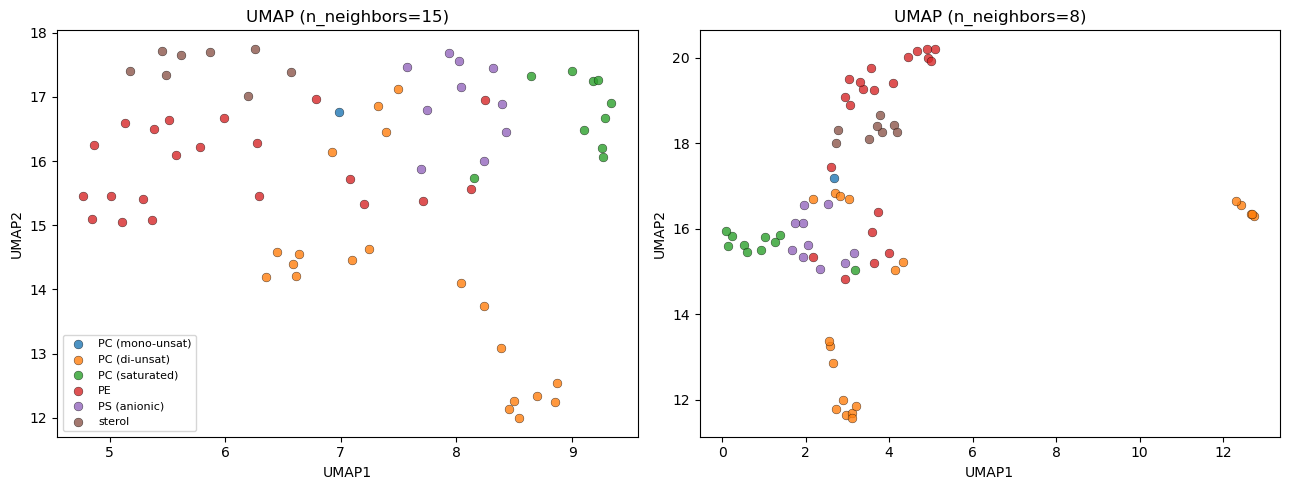

In [14]:
if HAS_UMAP:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, n_neigh in zip(axes, [15, 8]):
        reducer = umap_lib.UMAP(n_components=2, n_neighbors=n_neigh,
                                min_dist=0.1, random_state=0)
        Z_u = reducer.fit_transform(X_z)
        for fam, color in FAMILY_COLORS.items():
            m = df['family'] == fam
            if m.any():
                ax.scatter(Z_u[m, 0], Z_u[m, 1], c=[color], s=40, alpha=0.8,
                           label=fam, edgecolor='k', lw=0.3)
        ax.set_title(f'UMAP (n_neighbors={n_neigh})')
        ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
        if n_neigh == 15:
            ax.legend(fontsize=8, loc='best')
    plt.tight_layout()
    plt.savefig(FIG_DIR / '06b_umap.png', dpi=150, bbox_inches='tight')
    plt.savefig(FIG_DIR / '06b_umap.pdf', bbox_inches='tight')
    plt.show()
else:
    print('UMAP skipped (umap-learn not installed). pip install umap-learn to enable.')


### 6c — Hierarchical clustering (Ward)

Dendrogram of the z-scored property vectors. Cut at k=4 to compare against
the partner-family taxonomy.

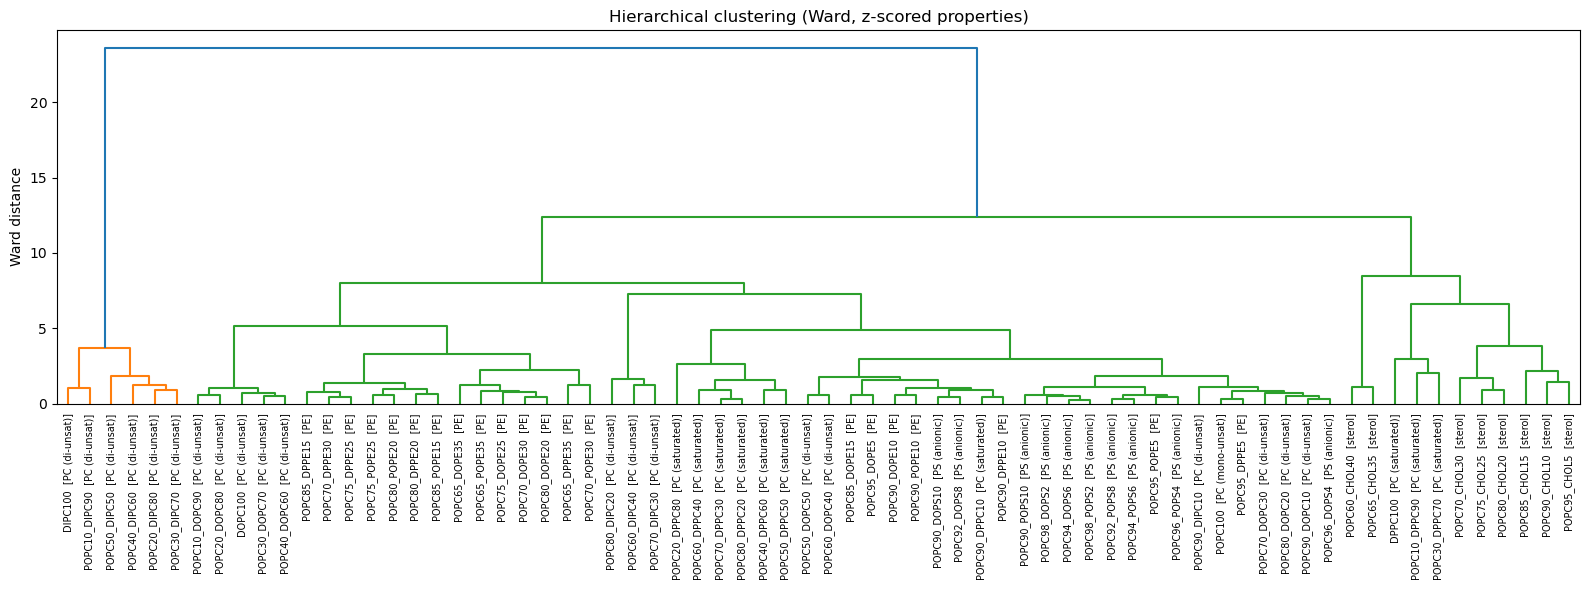


Cluster (k=4) × family contingency:
family      PC (di-unsat)  PC (mono-unsat)  PC (saturated)  PE  PS (anionic)  \
cluster_k4                                                                     
1                       6                0               0   0             0   
2                      14                1               7  21            10   
3                       0                0               0   0             0   
4                       0                0               3   0             0   

family      sterol  
cluster_k4          
1                0  
2                0  
3                2  
4                6  


In [15]:
dist = pdist(X_z, metric='euclidean')
Z_link = hierarchy.linkage(dist, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
labels = (df['composition'] + '  [' + df['family'] + ']').tolist()
hierarchy.dendrogram(Z_link, labels=labels, leaf_rotation=90,
                     leaf_font_size=7, color_threshold=0.7 * Z_link[:, 2].max(),
                     ax=ax)
ax.set_title('Hierarchical clustering (Ward, z-scored properties)')
ax.set_ylabel('Ward distance')
plt.tight_layout()
plt.savefig(FIG_DIR / '06c_dendrogram.png', dpi=150, bbox_inches='tight')
plt.savefig(FIG_DIR / '06c_dendrogram.pdf', bbox_inches='tight')
plt.show()

# Cut at k=4 and tabulate vs family
k = 4
clusters = hierarchy.fcluster(Z_link, t=k, criterion='maxclust')
df['cluster_k4'] = clusters
print(f'\nCluster (k={k}) × family contingency:')
print(pd.crosstab(df['cluster_k4'], df['family']))


### 6d — Outlier diagnostics

Mahalanobis distance and PCA reconstruction error in the z-scored 8-D space.
High values flag systems whose property profile is unusual relative to the bulk.

In [16]:
# Mahalanobis on z-scored features
mu = X_z.mean(axis=0)
cov = np.cov(X_z, rowvar=False) + 1e-6 * np.eye(X_z.shape[1])
inv_cov = np.linalg.inv(cov)
diff = X_z - mu
mahal = np.sqrt(np.einsum('ij,jk,ik->i', diff, inv_cov, diff))

# PCA reconstruction error using top-2 PCs
recon = (Z_pca[:, :2] @ pca.components_[:2]) + 0  # already centered (StandardScaler)
recon_err = np.linalg.norm(X_z - recon, axis=1)

out_df = pd.DataFrame({
    'composition': df['composition'],
    'family':      df['family'],
    'mahalanobis': mahal,
    'pca2_recon_err': recon_err,
}).sort_values('mahalanobis', ascending=False)

print('Top 10 by Mahalanobis distance:')
print(out_df.head(10).to_string(index=False))
print('\nTop 10 by PCA(top-2) reconstruction error:')
print(out_df.sort_values('pca2_recon_err', ascending=False).head(10).to_string(index=False))


Top 10 by Mahalanobis distance:
  composition         family  mahalanobis  pca2_recon_err
      DPPC100 PC (saturated)     5.517763        2.401880
POPC60_CHOL40         sterol     5.225234        2.310563
POPC65_CHOL35         sterol     5.065128        2.022350
POPC70_CHOL30         sterol     5.044706        1.552596
POPC10_DPPC90 PC (saturated)     4.586647        1.939866
      DIPC100  PC (di-unsat)     4.273485        1.677499
POPC20_DIPC80  PC (di-unsat)     4.236611        0.294900
POPC20_DPPC80 PC (saturated)     4.097117        2.289154
POPC10_DIPC90  PC (di-unsat)     4.047349        1.192532
 POPC95_CHOL5         sterol     3.852047        2.022441

Top 10 by PCA(top-2) reconstruction error:
  composition         family  mahalanobis  pca2_recon_err
      DPPC100 PC (saturated)     5.517763        2.401880
POPC60_CHOL40         sterol     5.225234        2.310563
POPC65_DOPE35             PE     3.779240        2.292273
POPC20_DPPC80 PC (saturated)     4.097117        2.289

## 7 — Time-series quality

The per-frame `raw_dict` series let us check stationarity and estimate
intrinsic frame-to-frame noise. `bending_modulus` is excluded — its `raw`
entry is the (q, |h(q)|²) spectrum, not a time series.

Frame spacing is `dt = 1.5 ns`; series cover roughly 1 µs of production after
the equilibration discard.

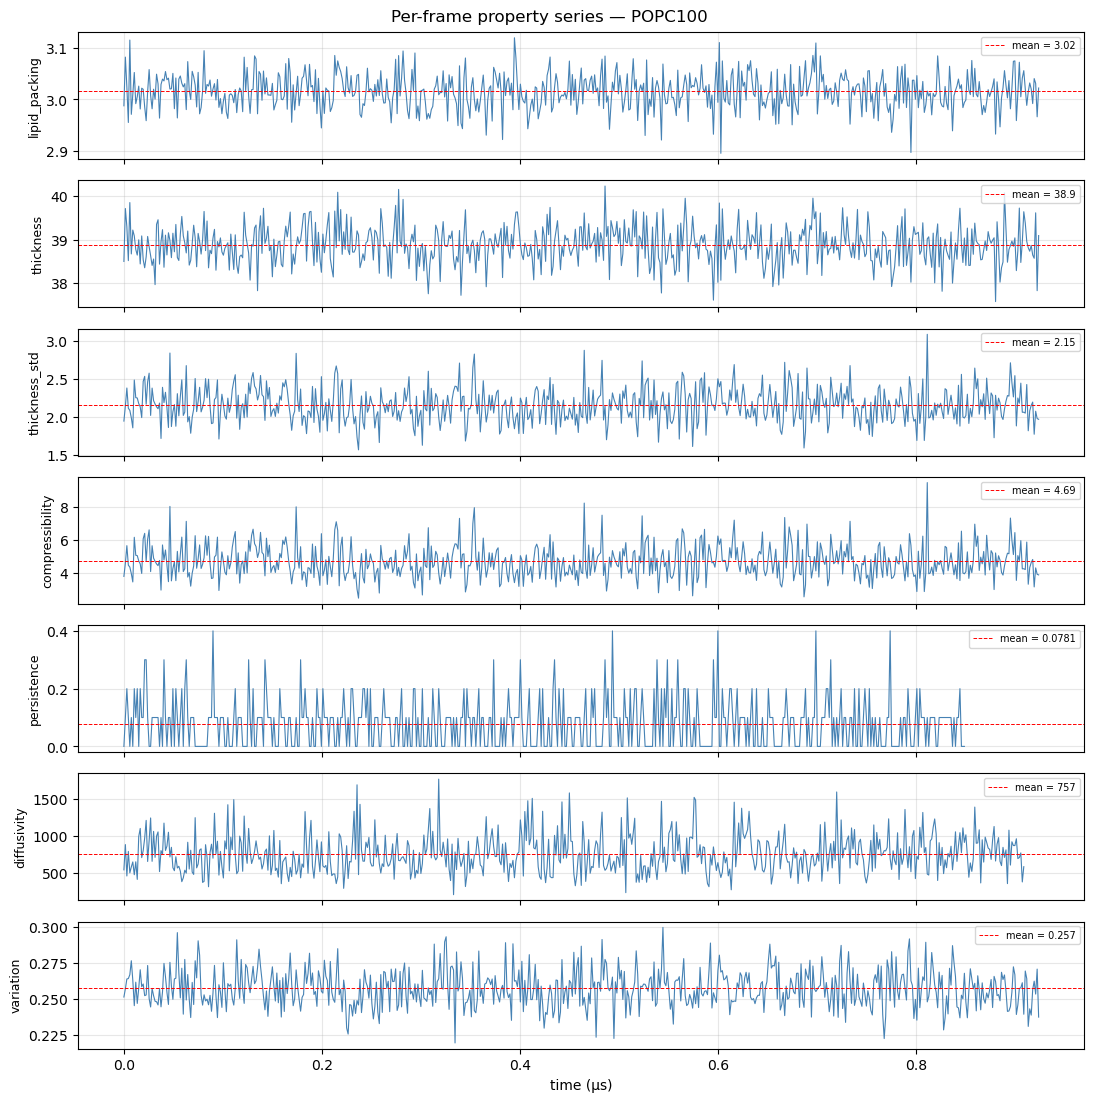

In [17]:
TS_PROPS = [p for p in PROPS if p != 'bending_modulus']
DT_NS = 1.5  # frame spacing

def get_series(comp, prop):
    v = np.asarray(RAW[comp][prop])
    if v.ndim != 1:
        return None
    return v

# 7a — representative trajectory
fig, axes = plt.subplots(len(TS_PROPS), 1, figsize=(11, 1.6 * len(TS_PROPS)), sharex=True)
comp_ref = REFERENCE
for ax, prop in zip(axes, TS_PROPS):
    s = get_series(comp_ref, prop)
    t = np.arange(len(s)) * DT_NS / 1000  # µs
    ax.plot(t, s, lw=0.8, color='steelblue')
    ax.axhline(np.mean(s), color='red', linestyle='--', lw=0.7,
               label=f'mean = {np.mean(s):.3g}')
    ax.set_ylabel(prop, fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('time (µs)')
fig.suptitle(f'Per-frame property series — {comp_ref}', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / '07a_timeseries_popc.png', dpi=150, bbox_inches='tight')
plt.savefig(FIG_DIR / '07a_timeseries_popc.pdf', bbox_inches='tight')
plt.show()


In [18]:
# 7b — Drift test (linear regression slope vs std), and 7c noise floor (within-system std vs between-system std)
def autocorr_time(x, max_lag=200):
    """Integrated autocorrelation time (sum until first negative ACF)."""
    x = np.asarray(x) - np.mean(x)
    var = np.var(x)
    if var <= 0:
        return np.nan
    n = len(x)
    max_lag = min(max_lag, n // 4)
    acf = []
    for k in range(1, max_lag + 1):
        c = np.dot(x[:-k], x[k:]) / (var * (n - k))
        if c < 0:
            break
        acf.append(c)
    return 1 + 2 * sum(acf)

quality_rows = []
for prop in TS_PROPS:
    within_stds = []
    drifts_rel  = []
    tau_list    = []
    for comp in df['composition']:
        s = get_series(comp, prop)
        if s is None or len(s) < 20:
            continue
        # drift: slope of linear fit, normalised by std
        t = np.arange(len(s))
        slope, _, _, _, _ = stats.linregress(t, s)
        drifts_rel.append(abs(slope) * len(s) / (np.std(s) + 1e-12))
        within_stds.append(np.std(s))
        tau_list.append(autocorr_time(s))

    within_std = np.mean(within_stds)
    between_std = df[prop].std(ddof=1)
    tau_mean   = np.nanmean(tau_list)
    n_eff      = (len(s) / tau_mean) if tau_mean > 0 else np.nan
    quality_rows.append({
        'property':     prop,
        'within_std':   within_std,           # mean per-system frame-to-frame std
        'between_std':  between_std,          # std across the 70 system means
        'snr (between/within)': between_std / within_std if within_std > 0 else np.nan,
        'autocorr_tau (frames)': tau_mean,
        'n_eff per system':     n_eff,
        'mean |drift|·N / std': np.mean(drifts_rel),  # large value → strong drift
    })

q_df = pd.DataFrame(quality_rows)
print('Time-series quality (per property):')
print(q_df.to_string(index=False))


Time-series quality (per property):
       property  within_std  between_std  snr (between/within)  autocorr_tau (frames)  n_eff per system  mean |drift|·N / std
  lipid_packing    0.034988     0.249088              7.119203               1.116681        552.530090              0.101862
      thickness    0.444148     1.383252              3.114397               1.232935        500.431944              0.136977
  thickness_std    0.222334     0.059926              0.269531               1.061837        581.068698              0.111164
compressibility    0.980928     0.262566              0.267671               1.065076        579.301576              0.112215
    persistence    0.082591     0.007596              0.091973               1.061608        534.095602              0.118998
    diffusivity  261.400757   139.291407              0.532865               1.879938        322.882965              0.170440
      variation    0.013250     0.007846              0.592173               1.073

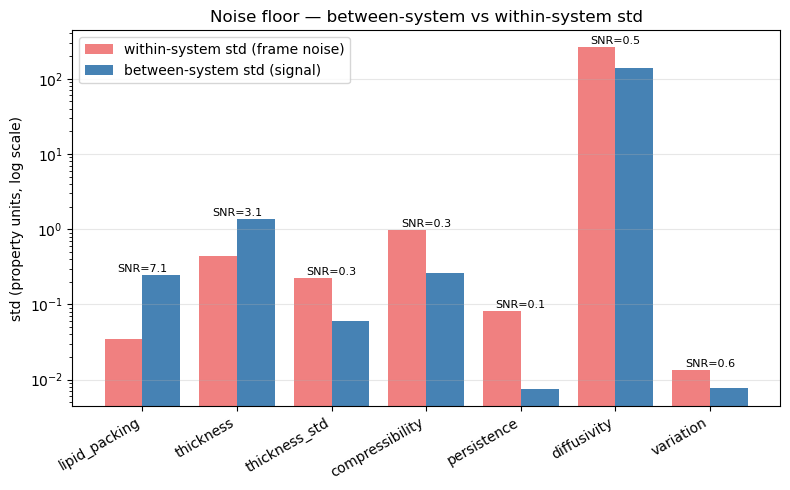

In [19]:
# 7c — Noise floor visualisation: within vs between-system std
fig, ax = plt.subplots(figsize=(8, 5))
xpos = np.arange(len(q_df))
w = 0.4
ax.bar(xpos - w/2, q_df['within_std'],  w, label='within-system std (frame noise)',  color='lightcoral')
ax.bar(xpos + w/2, q_df['between_std'], w, label='between-system std (signal)',     color='steelblue')
ax.set_yscale('log')
ax.set_xticks(xpos)
ax.set_xticklabels(q_df['property'], rotation=30, ha='right')
ax.set_ylabel('std (property units, log scale)')
ax.set_title('Noise floor — between-system vs within-system std')
for i, snr in enumerate(q_df['snr (between/within)']):
    ax.text(i, max(q_df.loc[i, 'within_std'], q_df.loc[i, 'between_std']) * 1.1,
            f'SNR={snr:.1f}', ha='center', fontsize=8)
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / '07b_noise_floor.png', dpi=150, bbox_inches='tight')
plt.savefig(FIG_DIR / '07b_noise_floor.pdf', bbox_inches='tight')
plt.show()


## 8 — Train/val/test split audit

The Tier A pipeline preprocesses graphs into `colab_lipid_gnn_subset/processed/{train,val,test}/chunk_*.pt`.
We list which compositions land in each split, and check whether property
distributions match across splits (a key concern after the test-narrowness
fix in early 2026-04).

In [20]:
import torch

CHUNKS_DIR = Path(CONFIG.paths.chunks_dir)
SPLITS = ['train', 'val', 'test']

split_compositions = {s: set() for s in SPLITS}
for s in SPLITS:
    sd = CHUNKS_DIR / s
    if not sd.exists():
        print(f'[skip] {sd} not present'); continue
    for chunk in sorted(sd.glob('chunk_*.pt')):
        graphs = torch.load(chunk, weights_only=False)
        for g in graphs:
            comp = getattr(g, 'composition', None)
            if comp is not None:
                split_compositions[s].add(comp)

for s in SPLITS:
    print(f'{s:>5s}: {len(split_compositions[s]):3d} compositions')


train:  48 compositions
  val:  11 compositions
 test:  11 compositions


In [21]:
# Build a per-composition split label (a composition usually lives in exactly one split)
def split_of(comp):
    hits = [s for s in SPLITS if comp in split_compositions[s]]
    if not hits:
        return None
    return hits[0] if len(hits) == 1 else '/'.join(hits)

df['split'] = df['composition'].map(split_of)
print(df['split'].value_counts(dropna=False))
print()
print('Compositions per split:')
for s in SPLITS:
    members = sorted(c for c, sp in zip(df['composition'], df['split']) if sp == s)
    print(f'  {s} ({len(members)}):', ', '.join(members) if members else '(none)')


split
train    48
val      11
test     11
Name: count, dtype: int64

Compositions per split:
  train (48): DIPC100, DOPC100, DPPC100, POPC100, POPC10_DPPC90, POPC20_DIPC80, POPC20_DOPC80, POPC30_DIPC70, POPC40_DOPC60, POPC40_DPPC60, POPC50_DIPC50, POPC50_DOPC50, POPC60_CHOL40, POPC60_DOPC40, POPC65_CHOL35, POPC65_DOPE35, POPC70_DIPC30, POPC70_DOPC30, POPC70_DOPE30, POPC70_DPPC30, POPC75_CHOL25, POPC75_DOPE25, POPC75_DPPE25, POPC75_POPE25, POPC80_CHOL20, POPC80_DIPC20, POPC80_DOPE20, POPC80_DPPE20, POPC80_POPE20, POPC85_CHOL15, POPC85_DOPE15, POPC85_DPPE15, POPC85_POPE15, POPC90_CHOL10, POPC90_DIPC10, POPC90_DOPC10, POPC90_DOPE10, POPC90_DPPC10, POPC90_POPE10, POPC90_POPS10, POPC92_DOPS8, POPC92_POPS8, POPC94_POPS6, POPC95_DOPE5, POPC95_POPE5, POPC96_DOPS4, POPC96_POPS4, POPC98_DOPS2
  val (11): POPC10_DIPC90, POPC10_DOPC90, POPC20_DPPC80, POPC50_DPPC50, POPC60_DIPC40, POPC65_POPE35, POPC70_DPPE30, POPC80_DOPC20, POPC94_DOPS6, POPC95_CHOL5, POPC95_DPPE5
  test (11): POPC30_DOPC70, POPC3

In [22]:
# Distribution match per property across splits — KS test vs train
present_splits = [s for s in SPLITS if (df['split'] == s).any()]
if 'train' in present_splits:
    rows = []
    for prop in PROPS:
        train_v = df.loc[df['split'] == 'train', prop].values
        for s in present_splits:
            other_v = df.loc[df['split'] == s, prop].values
            if s == 'train' or len(other_v) < 2:
                continue
            ks_stat, ks_p = stats.ks_2samp(train_v, other_v)
            rows.append({
                'property': prop, 'split': s,
                'n_train': len(train_v), 'n_other': len(other_v),
                'mean_train': train_v.mean(), 'mean_other': other_v.mean(),
                'std_train':  train_v.std(),  'std_other':  other_v.std(),
                'KS_stat': ks_stat, 'KS_p': ks_p,
            })
    print(pd.DataFrame(rows).to_string(index=False))
else:
    print('No split labels resolved — chunks may not be present.')


       property split  n_train  n_other  mean_train  mean_other  std_train  std_other  KS_stat     KS_p
  lipid_packing   val       48       11    3.074132    3.009460   0.263527   0.155041 0.204545 0.774293
  lipid_packing  test       48       11    3.074132    3.099879   0.263527   0.239806 0.344697 0.188331
      thickness   val       48       11   38.884318   38.728452   1.355326   1.529482 0.191288 0.827515
      thickness  test       48       11   38.884318   39.202162   1.355326   1.235329 0.344697 0.188331
  thickness_std   val       48       11    2.157371    2.174117   0.059207   0.053886 0.255682 0.510529
  thickness_std  test       48       11    2.157371    2.171398   0.059207   0.063225 0.225379 0.670824
compressibility   val       48       11    4.906922    4.972792   0.256810   0.239870 0.276515 0.415227
compressibility  test       48       11    4.906922    4.964622   0.256810   0.286099 0.225379 0.670824
bending_modulus   val       48       11  146.401081  144.627702 

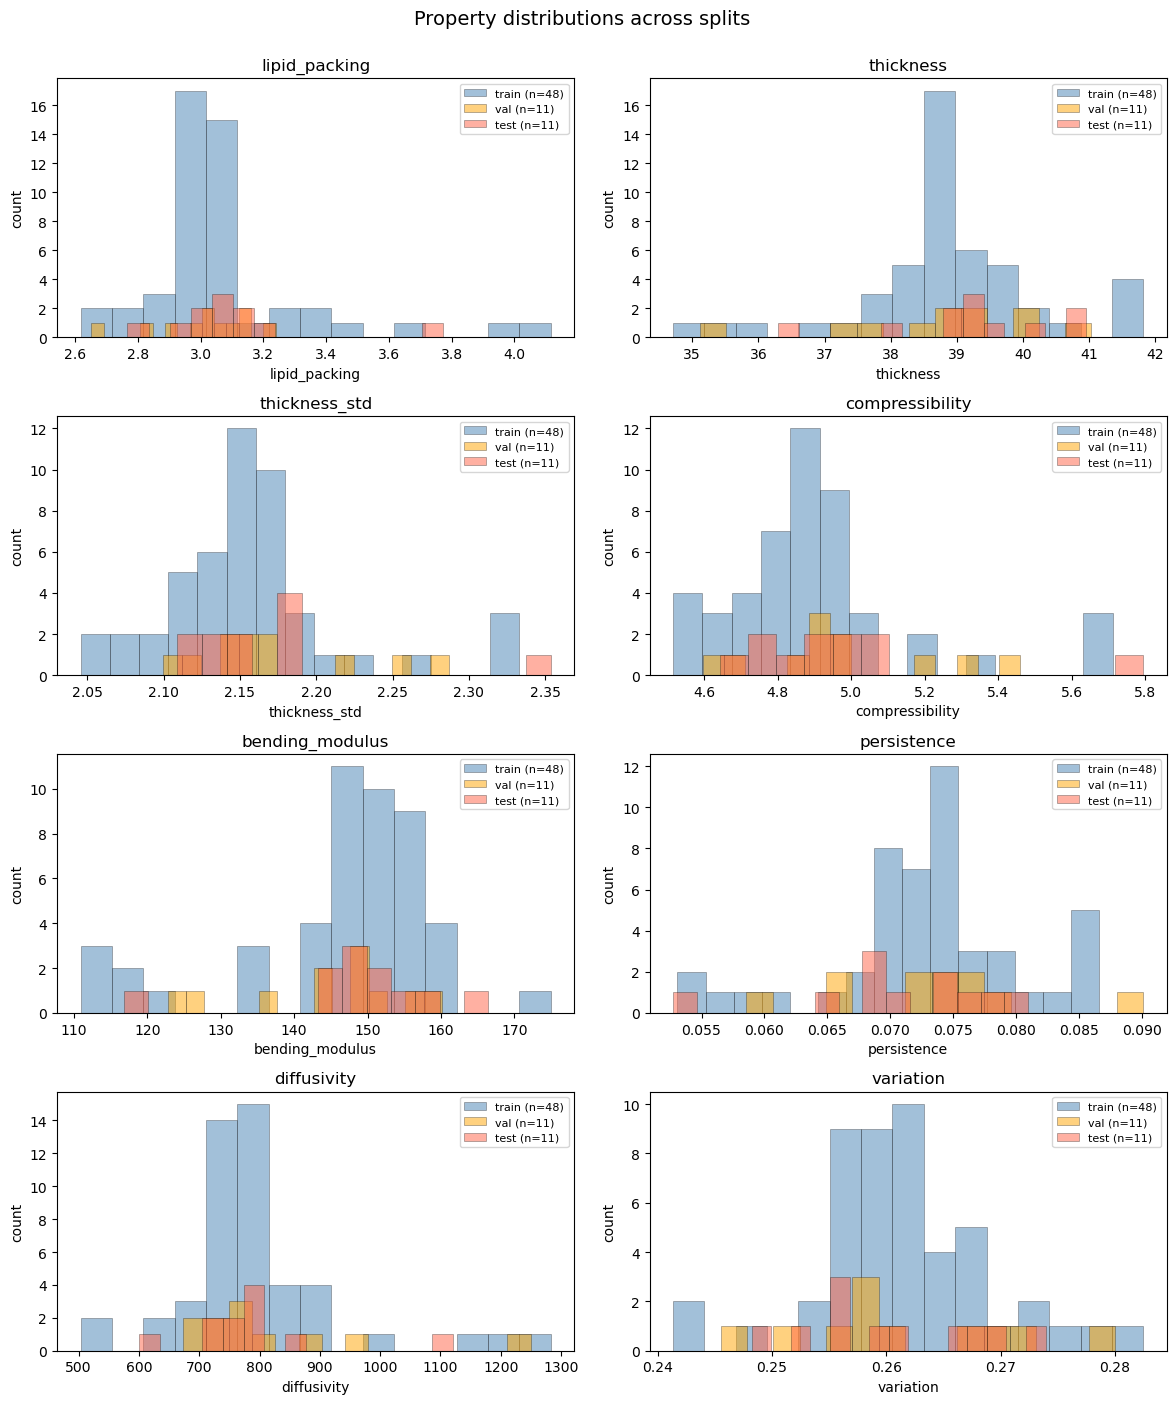

In [23]:
# Per-property split-coverage figure
present_splits = [s for s in SPLITS if (df['split'] == s).any()]
if present_splits:
    fig, axes = plt.subplots(4, 2, figsize=(12, 14))
    split_colors = {'train': 'steelblue', 'val': 'orange', 'test': 'tomato'}
    for ax, prop in zip(axes.flat, PROPS):
        for s in present_splits:
            v = df.loc[df['split'] == s, prop].values
            if len(v) == 0: continue
            ax.hist(v, bins=15, alpha=0.5, label=f'{s} (n={len(v)})',
                    color=split_colors.get(s, 'gray'), edgecolor='k', lw=0.4)
        ax.set_title(prop); ax.set_xlabel(prop); ax.set_ylabel('count')
        ax.legend(fontsize=8)
    fig.suptitle('Property distributions across splits', y=1.0, fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_DIR / '08_split_audit.png', dpi=150, bbox_inches='tight')
    plt.savefig(FIG_DIR / '08_split_audit.pdf', bbox_inches='tight')
    plt.show()
else:
    print('Skipped — no chunked splits present.')


## Wrap-up

Saved figures and tables under `results/dataset_analysis/`:

- `dataset_table.csv` — one row per composition, parsed composition + 8 properties
- `figures/01_coverage.{png,pdf}`           — composition coverage heatmap
- `figures/03_univariate.{png,pdf}`         — property distributions
- `figures/04a_correlations.{png,pdf}`      — Pearson + Spearman matrices
- `figures/04b_pairplot.{png,pdf}`          — full pairplot
- `figures/04c_helfrich.{png,pdf}`          — Helfrich proxy scatter
- `figures/05_titration.{png,pdf}`          — titration curves
- `figures/06a_pca.{png,pdf}`               — scree, PC1/PC2, loadings
- `figures/06b_umap.{png,pdf}`              — UMAP (if available)
- `figures/06c_dendrogram.{png,pdf}`        — Ward clustering
- `figures/07a_timeseries_popc.{png,pdf}`   — POPC100 reference trajectories
- `figures/07b_noise_floor.{png,pdf}`       — within vs between-system std
- `figures/08_split_audit.{png,pdf}`        — train/val/test distribution check


In [24]:
print('Outputs:')
for p in sorted(FIG_DIR.glob('*.png')):
    print(f'  {p.relative_to(OUT_DIR.parent)}')
print(f'  {table_path.relative_to(OUT_DIR.parent)}')


Outputs:
  dataset_analysis/figures/01_coverage.png
  dataset_analysis/figures/03_univariate.png
  dataset_analysis/figures/04a_correlations.png
  dataset_analysis/figures/04b_pairplot.png
  dataset_analysis/figures/04c_helfrich.png
  dataset_analysis/figures/05_titration.png
  dataset_analysis/figures/06a_pca.png
  dataset_analysis/figures/06b_umap.png
  dataset_analysis/figures/06c_dendrogram.png
  dataset_analysis/figures/07a_timeseries_popc.png
  dataset_analysis/figures/07b_noise_floor.png
  dataset_analysis/figures/08_split_audit.png
  dataset_analysis/dataset_table.csv
